**SHIVAM NARENDRA SINGH**

*5135873*

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [7]:
df=pd.read_csv('spam_ham_dataset.csv',encoding='latin1')

In [3]:
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5171 non-null   int64 
 1   label       5171 non-null   object
 2   text        5171 non-null   object
 3   label_num   5171 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 161.7+ KB


In [5]:
df.describe()

,Unnamed: 0,label_num
count,5171.000000,5171.000000
mean,2585.000000,0.289886
std,1492.883452,0.453753
min,0.000000,0.000000
25%,1292.500000,0.000000
50%,2585.000000,0.000000
75%,3877.500000,1.000000
max,5170.000000,1.000000


In [6]:
df.isnull().sum()   

Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64

In [9]:
df = df[['label', 'text']]  # keep only label & text columns
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
print(df['label'].value_counts())

label
0    3672
1    1499
Name: count, dtype: int64


C:\Users\naren\AppData\Local\Temp\ipykernel_9952\2659614661.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = df['label'].map({'ham': 0, 'spam': 1})


In [10]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [12]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_tfidf, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [13]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_tfidf, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
from sklearn.svm import SVC

svm = SVC(kernel='linear', probability=True, random_state=42)
svm.fit(X_train_tfidf, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

models = {'KNN': knn, 'DecisionTree': dt, 'SVM': svm}

for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    print(f"\n{name} Metrics:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



KNN Metrics:
Accuracy: 0.9526570048309179
Precision: 0.9114754098360656
Recall: 0.9266666666666666
Confusion Matrix:
 [[708  27]
 [ 22 278]]

DecisionTree Metrics:
Accuracy: 0.821256038647343
Precision: 0.6215644820295984
Recall: 0.98
Confusion Matrix:
 [[556 179]
 [  6 294]]

SVM Metrics:
Accuracy: 0.9816425120772947
Precision: 0.9517684887459807
Recall: 0.9866666666666667
Confusion Matrix:
 [[720  15]
 [  4 296]]


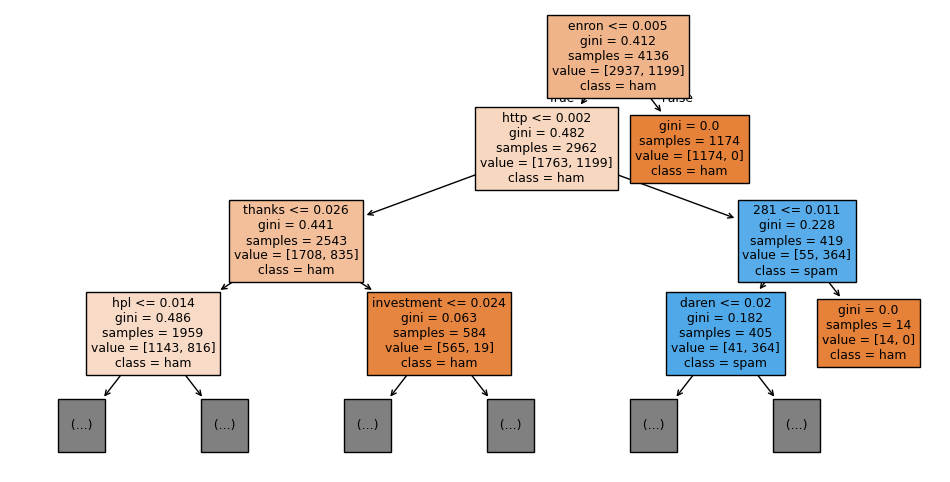

In [16]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plot_tree(dt, filled=True, feature_names=tfidf.get_feature_names_out(), class_names=['ham','spam'], max_depth=3)
plt.show()


In [17]:
samples = ["You won a free ticket!", "Are we meeting today?"]
samples_tfidf = tfidf.transform(samples)

for name, model in models.items():
    print(f"{name} prediction:", model.predict(samples_tfidf))


KNN prediction: [1 0]
DecisionTree prediction: [1 1]
SVM prediction: [1 0]
